# Modelos — Etapa 1: Baselines

Pipeline: EDA → limpeza de tipos → tratamento de "No service" → features derivadas → split treino/teste → fit do encoder+scaler no treino → transform em ambos → **baseline (Dummy + LR)**

Métricas avaliadas:
- **Técnicas**: Accuracy, F1-Score, Precision, Recall, ROC-AUC, PR-AUC
- **Negócio**: Custo de churn evitado (TP), custo falso positivo (FP), churn perdido (FN), lucro líquido

## Setup

In [1]:
import pandas as pd
import numpy as np
import random
import hashlib
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from utils import preprocessing, prepare_train_val_test
from utils import mlp_preprocessing, mlp_prepare_train_val_test

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TEST_SIZE = 0.2

## Carregamento e Pré-processamento

In [2]:
DATASET_PATH = "../data/dataset/telco_customer_churn.csv"

df_raw = pd.read_csv(DATASET_PATH)
df = df_raw.copy()
df.rename(columns={"Churn": "target"}, inplace=True)
df["target"] = df["target"].map({"Yes": 1, "No": 0})

# Versionamento do dataset
with open(DATASET_PATH, "rb") as f:
    DATASET_VERSION = hashlib.md5(f.read()).hexdigest()
print(f"Dataset MD5: {DATASET_VERSION}")
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True).round(4)}")

Dataset MD5: 0f9de68e012bd3aed5fa7cdc9fc421af
Shape: (7043, 21)
Target distribution:
target
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [3]:
# Pré-processamento: limpeza, encoding, features derivadas (conforme docs/feature-engineering.md)
df_encoded = preprocessing(df)

# Split treino/teste com StandardScaler (mode='baseline' → sem validation set)
X_train, X_test, y_train, y_test = prepare_train_val_test(
    df_encoded, test_size=TEST_SIZE, random_state=SEED, mode="baseline"
)

print(f"Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Target rate (treino): {y_train.mean():.4f}")

Colunas categóricas (3): ['Contract', 'PaymentMethod', 'tenure_bucket']

  Contract: 3 valores únicos → ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: 4 valores únicos → ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  tenure_bucket: 4 valores únicos → ['0-12', '25-48', '13-24', '49+']
Categories (4, object): ['0-12' < '13-24' < '25-48' < '49+']
Treino: 5634 amostras, 22 features
Teste:  1409 amostras
Target rate (treino): 0.2654


## Função de Avaliação

Métricas técnicas + duas métricas de negócio complementares:

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| LTV por cliente retido (TP) | R$ 500 | Receita preservada ao reter um cliente que churaria |
| Custo de retenção (TP + FP) | R$ 100 | Custo da campanha/desconto oferecido |

| Métrica de negócio | Fórmula | Pergunta que responde |
|--------------------|---------|----------------------|
| **ROI Campanha** | `ganho_tp - custo_fp` | "A campanha de retenção se paga?" |
| **Lucro Líquido** | `ganho_tp - custo_fp - perda_fn` | "Qual o impacto econômico total de usar este modelo?" |

In [4]:
VALOR_CLIENTE_LTV = 500  # Ganho ao reter um TP
CUSTO_RETENCAO = 100     # Custo da oferta (desconto/cupom) para TP e FP


def evaluate_model(model, X_test, y_test):
    """Avalia modelo com métricas técnicas e de negócio. Retorna dict de métricas e confusion matrix."""
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = np.zeros(len(y_test))

    # Métricas técnicas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1)
    roc = roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5
    pr_prec, pr_rec, _ = precision_recall_curve(y_test, y_proba)
    pr = auc(pr_rec, pr_prec)

    # Métricas de negócio
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ganho_tp = tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO)
    custo_fp = fp * CUSTO_RETENCAO
    perda_fn = fn * VALOR_CLIENTE_LTV
    roi_campanha = ganho_tp - custo_fp                  # ROI da acao de retencao
    lucro_liquido = ganho_tp - custo_fp - perda_fn      # Impacto economico total do modelo

    metrics = {
        "accuracy": acc,
        "f1_score": f1,
        "precision": prec,
        "recall": rec,
        "roc_auc": roc,
        "pr_auc": pr,
        "custo_churn_evitado_BRL": ganho_tp,
        "custo_falso_positivo_BRL": custo_fp,
        "custo_churn_perdido_BRL": perda_fn,
        "roi_campanha_BRL": roi_campanha,
        "lucro_liquido_BRL": lucro_liquido,
    }

    # Print resumo
    print(classification_report(y_test, y_pred, target_names=["Sem churn", "Com churn"]))
    print(f"  ROC-AUC:  {roc:.4f}")
    print(f"  PR-AUC:   {pr:.4f}")
    print(f"  TP Custo churn evitado:  R$ {ganho_tp:,.0f}")
    print(f"  FN Custo churn perdido:  R$ {perda_fn:,.0f}")
    print(f"  FP Custo falso positivo: R$ {custo_fp:,.0f}")
    print(f"  ROI Campanha:            R$ {roi_campanha:,.0f}  (ganho_tp - custo_fp)")
    print(f"  Lucro Liquido:           R$ {lucro_liquido:,.0f}  (ganho_tp - custo_fp - perda_fn)")

    return metrics, cm

## Baseline 1: DummyClassifier

Baseline ingênuo — sempre prediz a classe majoritária (`most_frequent`). Serve como piso: qualquer modelo real precisa superar isso.

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)

print("=" * 60)
print(" DummyClassifier (most_frequent)")
print("=" * 60)
dummy_metrics, dummy_cm = evaluate_model(dummy, X_test, y_test)

 DummyClassifier (most_frequent)
              precision    recall  f1-score   support

   Sem churn       0.73      1.00      0.85      1035
   Com churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

  ROC-AUC:  0.5000
  PR-AUC:   0.6327
  TP Custo churn evitado:  R$ 0
  FN Custo churn perdido:  R$ 187,000
  FP Custo falso positivo: R$ 0
  ROI Campanha:            R$ 0  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ -187,000  (ganho_tp - custo_fp - perda_fn)


## Baseline 2: Regressão Logística

Baseline com `class_weight='balanced'` para compensar o desbalanceamento (~26% churn). Usa solver `lbfgs` com `max_iter=1000`.

In [6]:
lr = LogisticRegression(
    max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
)
lr.fit(X_train, y_train)

print("=" * 60)
print(" LogisticRegression (balanced)")
print("=" * 60)
lr_metrics, lr_cm = evaluate_model(lr, X_test, y_test)

 LogisticRegression (balanced)
              precision    recall  f1-score   support

   Sem churn       0.91      0.73      0.81      1035
   Com churn       0.51      0.80      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

  ROC-AUC:  0.8473
  PR-AUC:   0.6660
  TP Custo churn evitado:  R$ 119,200
  FN Custo churn perdido:  R$ 38,000
  FP Custo falso positivo: R$ 28,200
  ROI Campanha:            R$ 91,000  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 53,000  (ganho_tp - custo_fp - perda_fn)


## Comparacao Visual

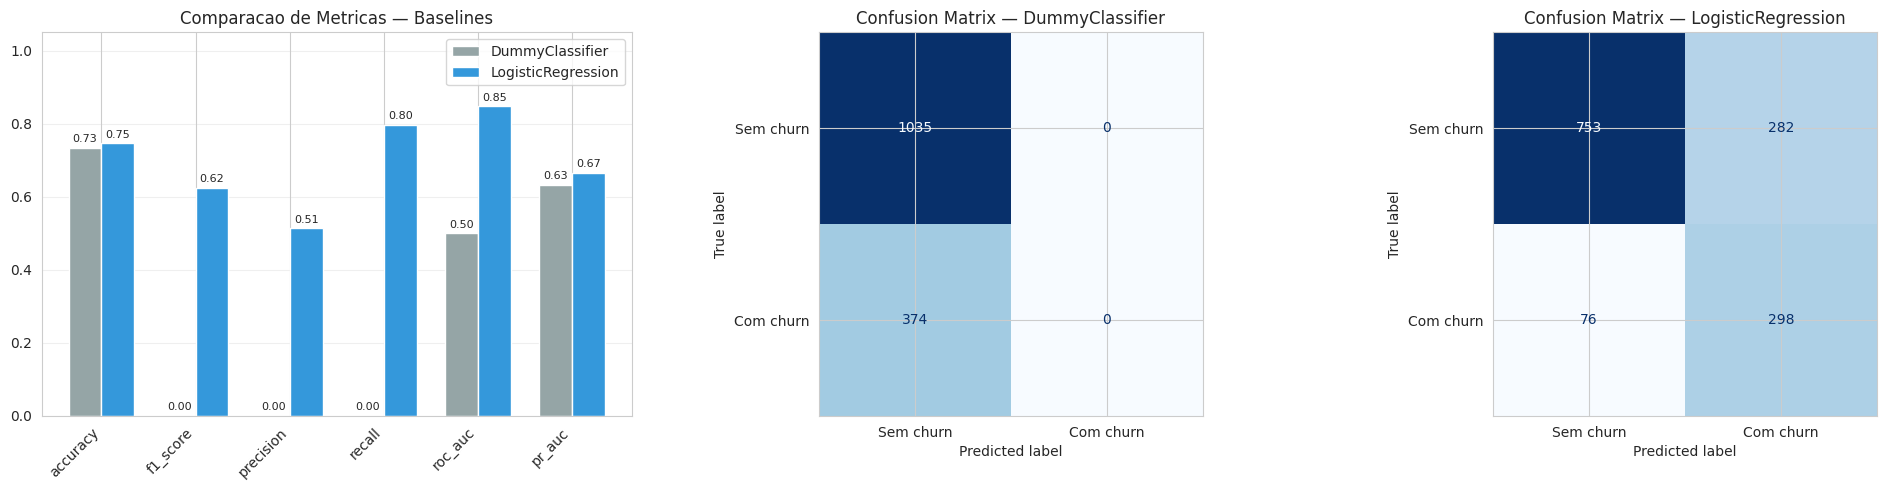

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- 1. Métricas lado a lado ---
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35
bars1 = axes[0].bar(x - width / 2, dummy_vals, width, label="DummyClassifier", color="#95a5a6")
bars2 = axes[0].bar(x + width / 2, lr_vals, width, label="LogisticRegression", color="#3498db")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparacao de Metricas — Baselines")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8,
    )
for bar in bars2:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8,
    )

# --- 2. Confusion Matrix — Dummy ---
ConfusionMatrixDisplay(dummy_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("Confusion Matrix — DummyClassifier")

# --- 3. Confusion Matrix — LR ---
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("Confusion Matrix — LogisticRegression")

plt.tight_layout()
plt.show()

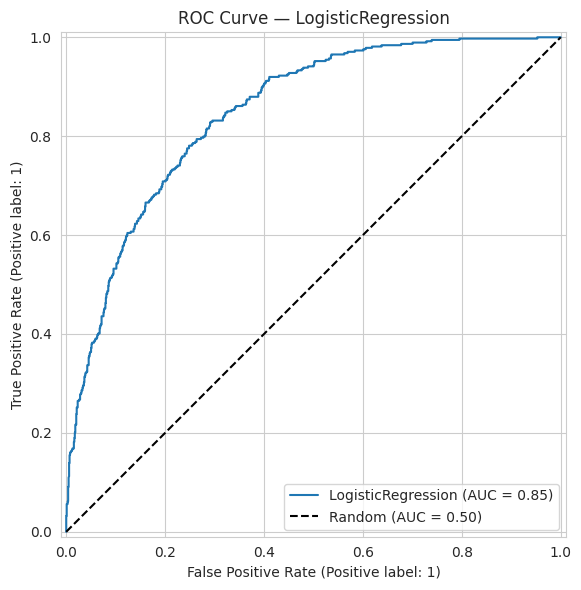

In [8]:
# ROC Curve — somente LR (Dummy com most_frequent não tem curva informativa)
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name="LogisticRegression")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — LogisticRegression")
ax.legend()
plt.tight_layout()
plt.show()

## Resumo dos Baselines

In [9]:
all_metrics = list(dummy_metrics.keys())
resumo = pd.DataFrame({
    "Metrica": all_metrics,
    "DummyClassifier": [dummy_metrics[m] for m in all_metrics],
    "LogisticRegression": [lr_metrics[m] for m in all_metrics],
})

# Formatar valores monetários
for col in ["DummyClassifier", "LogisticRegression"]:
    resumo[col] = resumo.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

print("=" * 60)
print(" RESUMO DOS BASELINES")
print("=" * 60)
resumo

 RESUMO DOS BASELINES


,Metrica,DummyClassifier,LogisticRegression
0,accuracy,0.7346,0.7459
1,f1_score,0.0000,0.6247
2,precision,0.0000,0.5138
3,recall,0.0000,0.7968
4,roc_auc,0.5000,0.8473
5,pr_auc,0.6327,0.6660
6,custo_churn_evitado_BRL,R$ 0,"R$ 119,200"
7,custo_falso_positivo_BRL,R$ 0,"R$ 28,200"
8,custo_churn_perdido_BRL,"R$ 187,000","R$ 38,000"
9,roi_campanha_BRL,R$ 0,"R$ 91,000"


## Etapa 2: MLP (PyTorch)

**Objetivo**: superar os baselines (especialmente a Regressão Logística) com uma rede neural MLP.

**Diferenças no pré-processamento** (via `mlp_preprocessing`):
- Mantém `tenure` contínuo (ao invés de apenas buckets)
- Preserva distinção DSL vs Fiber optic (`has_fiber`, `has_dsl`) — Fiber tem 41.9% churn vs 19% DSL
- Mantém `SeniorCitizen`, `PaperlessBilling`, `Dependents` (features preditivas que eram dropadas)
- Mantém `avg_charges_per_month` como feature contínua
- 6 features contínuas escaladas (vs. 4 nos baselines)

**Arquitetura escolhida**:
- 2 camadas ocultas (48 → 24) — dimensionada para o dataset (~4.5k treino)
- BatchNorm + GELU + Dropout(0.1)
- Loss: BCEWithLogitsLoss com `pos_weight`
- Otimizador: Adam (sem weight decay — BatchNorm + early stopping já regularizam)
- Early stopping no validation loss (paciência = 25 épocas)

**Justificativa da redução**:
- Arquitetura anterior (128→64→32, 13.7k params) era superdimensionada para ~4.5k amostras
- Nova arquitetura (~2k params) tem ratio samples/params saudável (~2.5:1)
- GELU evita dead neurons (problema do ReLU em redes pequenas)
- Dropout reduzido de 0.3→0.1: menos regularização permite aprendizado efetivo

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reprodutibilidade PyTorch
torch.manual_seed(SEED)

# Forçar CPU (versão do PyTorch sem kernels compatíveis com esta GPU)
device = torch.device("cpu")
print(f"Device: {device}")

Device: cpu


### Preparação dos dados (com validation set)

In [11]:
# Pré-processamento otimizado para MLP (preserva mais sinal contínuo e categórico)
df_mlp = df.copy()
df_mlp_encoded = mlp_preprocessing(df_mlp)

# Split com validation set para early stopping
X_train_mlp, X_val_mlp, X_test_mlp, y_train_mlp, y_val_mlp, y_test_mlp = mlp_prepare_train_val_test(
    df_mlp_encoded, test_size=TEST_SIZE, random_state=SEED
)

print(f"Treino:     {X_train_mlp.shape[0]} amostras, {X_train_mlp.shape[1]} features")
print(f"Validação:  {X_val_mlp.shape[0]} amostras")
print(f"Teste:      {X_test_mlp.shape[0]} amostras")
print(f"Target rate (treino): {y_train_mlp.mean():.4f}")
print(f"\nFeatures: {list(X_train_mlp.columns)}")

# pos_weight para BCEWithLogitsLoss
n_pos = y_train_mlp.sum()
n_neg = len(y_train_mlp) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"\npos_weight: {pos_weight.item():.2f} (neg/pos = {n_neg}/{n_pos})")

Colunas categóricas (3): ['Contract', 'PaymentMethod', 'tenure_bucket']

  Contract: 3 valores únicos → ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: 4 valores únicos → ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  tenure_bucket: 4 valores únicos → ['0-12', '25-48', '13-24', '49+']
Categories (4, object): ['0-12' < '13-24' < '25-48' < '49+']
Treino:     4507 amostras, 28 features
Validação:  1127 amostras
Teste:      1409 amostras
Target rate (treino): 0.2654

Features: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'has_fiber', 'has_dsl', 'avg_charges_per_month', 'charge_vs_expected', 'num_services', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mail

In [12]:
# Converter para tensores PyTorch
def to_tensors(X, y):
    return (
        torch.tensor(X.values.astype(np.float32), dtype=torch.float32),
        torch.tensor(y.values.astype(np.float32), dtype=torch.float32),
    )

X_train_t, y_train_t = to_tensors(X_train_mlp, y_train_mlp)
X_val_t, y_val_t = to_tensors(X_val_mlp, y_val_mlp)
X_test_t, y_test_t = to_tensors(X_test_mlp, y_test_mlp)

# DataLoaders (batch_size=32 para mais updates por epoch em dataset pequeno)
BATCH_SIZE = 32

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False
)

print(f"Batches — treino: {len(train_loader)}, val: {len(val_loader)}, teste: {len(test_loader)}")

Batches — treino: 141, val: 36, teste: 45


### Definição da Arquitetura MLP

In [13]:
class ChurnMLP(nn.Module):
    """MLP para predição de churn com BatchNorm e Dropout."""

    def __init__(self, input_dim, hidden_dims=(48, 24), dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))  # saída logit (sem sigmoid)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)


input_dim = X_train_t.shape[1]
model = ChurnMLP(input_dim).to(device)
print(model)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=48, out_features=24, bias=True)
    (5): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=24, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 2,737


### Loop de Treinamento com Early Stopping

In [14]:
# Hiperparâmetros
EPOCHS = 200
LR = 1e-3
PATIENCE = 25

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)  # sem weight_decay (BatchNorm + early stopping regularizam)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)

# Early stopping state
best_val_loss = float("inf")
best_model_state = None
epochs_no_improve = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    # --- Treino ---
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- Validação ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * len(X_batch)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epochs_no_improve == 0:
        marker = " ✓ best" if epochs_no_improve == 0 else ""
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}{marker}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping na época {epoch} (paciência={PATIENCE})")
        break

# Restaurar melhor modelo
model.load_state_dict(best_model_state)
print(f"\nMelhor val loss: {best_val_loss:.4f}")
print(f"Épocas totais: {len(train_losses)}")

Epoch   1 | Train Loss: 0.8250 | Val Loss: 0.7283 ✓ best
Epoch   2 | Train Loss: 0.7388 | Val Loss: 0.7076 ✓ best
Epoch  10 | Train Loss: 0.6920 | Val Loss: 0.7261
Epoch  20 | Train Loss: 0.6669 | Val Loss: 0.7388

Early stopping na época 27 (paciência=25)

Melhor val loss: 0.7076
Épocas totais: 27


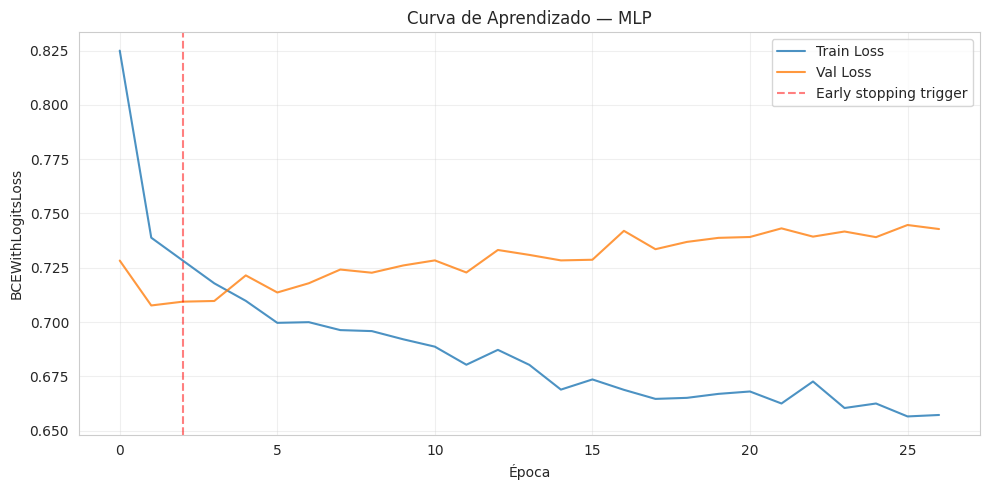

In [15]:
# Curva de aprendizado
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train Loss", alpha=0.8)
ax.plot(val_losses, label="Val Loss", alpha=0.8)
ax.axvline(len(train_losses) - PATIENCE, color="red", linestyle="--", alpha=0.5, label="Early stopping trigger")
ax.set_xlabel("Época")
ax.set_ylabel("BCEWithLogitsLoss")
ax.set_title("Curva de Aprendizado — MLP")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Avaliação do MLP no conjunto de teste

Usamos a mesma função `evaluate_model` dos baselines para garantir comparabilidade. Para isso, criamos um wrapper sklearn-compatible.

In [16]:
class PyTorchWrapper:
    """Wrapper para usar modelo PyTorch com evaluate_model (interface sklearn)."""

    def __init__(self, model, device, threshold=0.5):
        self.model = model
        self.device = device
        self.threshold = threshold

    def predict_proba(self, X):
        self.model.eval()
        if isinstance(X, pd.DataFrame):
            X = torch.tensor(X.values.astype(np.float32), dtype=torch.float32)
        X = X.to(self.device)
        with torch.no_grad():
            logits = self.model(X)
            probs = torch.sigmoid(logits).cpu().numpy()
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)


mlp_wrapper = PyTorchWrapper(model, device)

print("=" * 60)
print(" MLP (PyTorch)")
print("=" * 60)
mlp_metrics, mlp_cm = evaluate_model(mlp_wrapper, X_test_mlp, y_test_mlp)

 MLP (PyTorch)
              precision    recall  f1-score   support

   Sem churn       0.91      0.69      0.79      1035
   Com churn       0.49      0.80      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409

  ROC-AUC:  0.8412
  PR-AUC:   0.6505
  TP Custo churn evitado:  R$ 120,400
  FN Custo churn perdido:  R$ 36,500
  FP Custo falso positivo: R$ 31,600
  ROI Campanha:            R$ 88,800  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 52,300  (ganho_tp - custo_fp - perda_fn)


### Comparação: MLP vs. Baselines

In [17]:
# Tabela comparativa: Baselines vs. MLP (novo preprocessing)
all_metric_keys = list(dummy_metrics.keys())
resumo_parcial = pd.DataFrame({
    "Metrica": all_metric_keys,
    "DummyClassifier": [dummy_metrics[m] for m in all_metric_keys],
    "LogisticRegression": [lr_metrics[m] for m in all_metric_keys],
    "MLP": [mlp_metrics[m] for m in all_metric_keys],
})

resumo_parcial_display = resumo_parcial.copy()
for col in ["DummyClassifier", "LogisticRegression", "MLP"]:
    resumo_parcial_display[col] = resumo_parcial.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

print("=" * 70)
print(" COMPARAÇÃO: Baselines vs. MLP (novo preprocessing, config default)")
print("=" * 70)
resumo_parcial_display

 COMPARAÇÃO: Baselines vs. MLP (novo preprocessing, config default)


,Metrica,DummyClassifier,LogisticRegression,MLP
0,accuracy,0.7346,0.7459,0.7239
1,f1_score,0.0000,0.6247,0.6075
2,precision,0.0000,0.5138,0.4878
3,recall,0.0000,0.7968,0.8048
4,roc_auc,0.5000,0.8473,0.8412
5,pr_auc,0.6327,0.6660,0.6505
6,custo_churn_evitado_BRL,R$ 0,"R$ 119,200","R$ 120,400"
7,custo_falso_positivo_BRL,R$ 0,"R$ 28,200","R$ 31,600"
8,custo_churn_perdido_BRL,"R$ 187,000","R$ 38,000","R$ 36,500"
9,roi_campanha_BRL,R$ 0,"R$ 91,000","R$ 88,800"


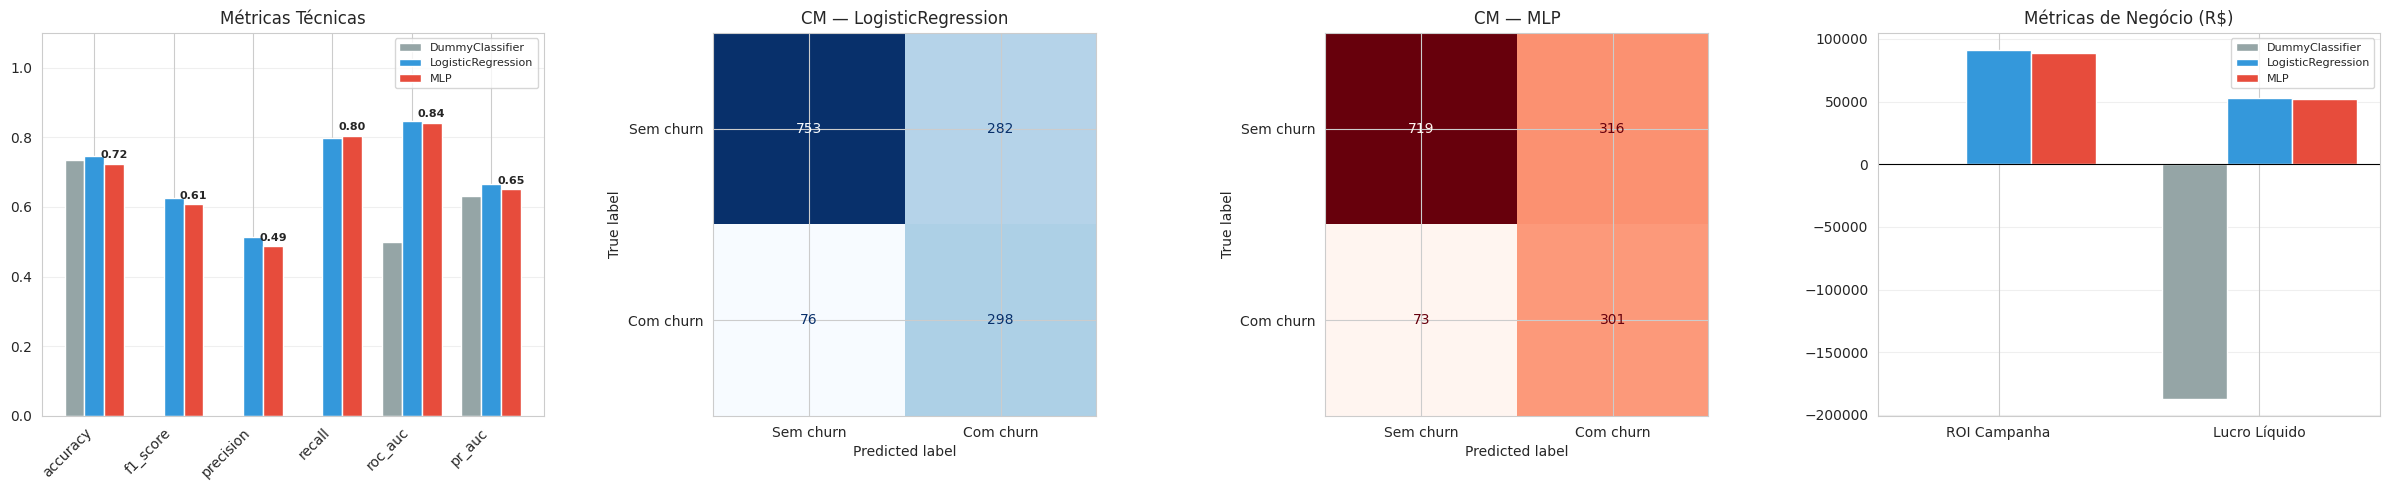

In [18]:
# Visualização comparativa — Baselines vs MLP (config default)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# --- 1. Métricas técnicas lado a lado ---
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]
mlp_vals = [mlp_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.25
axes[0].bar(x - width, dummy_vals, width, label="DummyClassifier", color="#95a5a6")
axes[0].bar(x, lr_vals, width, label="LogisticRegression", color="#3498db")
bars_mlp = axes[0].bar(x + width, mlp_vals, width, label="MLP", color="#e74c3c")
for bar in bars_mlp:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Métricas Técnicas")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# --- 2. Confusion Matrix — LR ---
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("CM — LogisticRegression")

# --- 3. Confusion Matrix — MLP ---
ConfusionMatrixDisplay(mlp_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[2], cmap="Reds", colorbar=False
)
axes[2].set_title("CM — MLP")

# --- 4. Métricas de negócio ---
biz_metrics = ["roi_campanha_BRL", "lucro_liquido_BRL"]
biz_labels = ["ROI Campanha", "Lucro Líquido"]
dummy_biz = [dummy_metrics[m] for m in biz_metrics]
lr_biz = [lr_metrics[m] for m in biz_metrics]
mlp_biz = [mlp_metrics[m] for m in biz_metrics]

x_biz = np.arange(len(biz_metrics))
axes[3].bar(x_biz - width, dummy_biz, width, label="DummyClassifier", color="#95a5a6")
axes[3].bar(x_biz, lr_biz, width, label="LogisticRegression", color="#3498db")
axes[3].bar(x_biz + width, mlp_biz, width, label="MLP", color="#e74c3c")
axes[3].set_xticks(x_biz)
axes[3].set_xticklabels(biz_labels)
axes[3].set_title("Métricas de Negócio (R$)")
axes[3].legend(fontsize=8)
axes[3].grid(axis="y", alpha=0.3)
axes[3].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

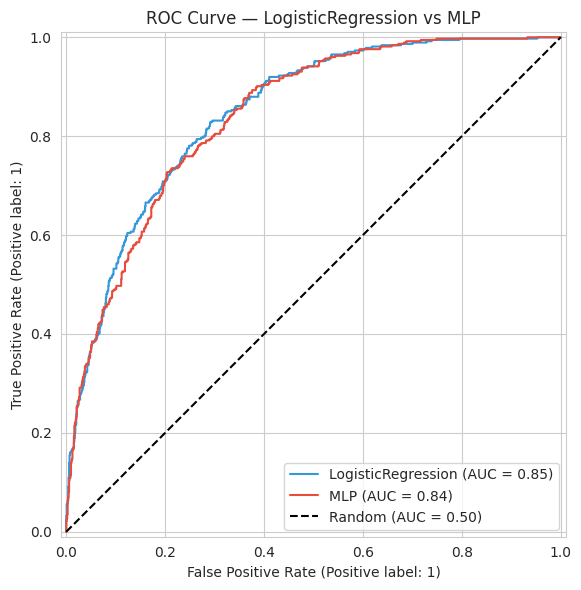

In [19]:
# ROC Curve — LR vs MLP
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name="LogisticRegression", color="#3498db")

# MLP ROC manual (wrapper não é sklearn estimator)
y_proba_mlp = mlp_wrapper.predict_proba(X_test_mlp)[:, 1]
from sklearn.metrics import RocCurveDisplay as RCD
RCD.from_predictions(y_test_mlp, y_proba_mlp, ax=ax, name="MLP", color="#e74c3c")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — LogisticRegression vs MLP")
ax.legend()
plt.tight_layout()
plt.show()

### Análise de Trade-off: Threshold vs. Custo

Variando o threshold de classificação para entender o trade-off entre falso positivo (custo de retenção desperdiçado) e falso negativo (churn perdido).

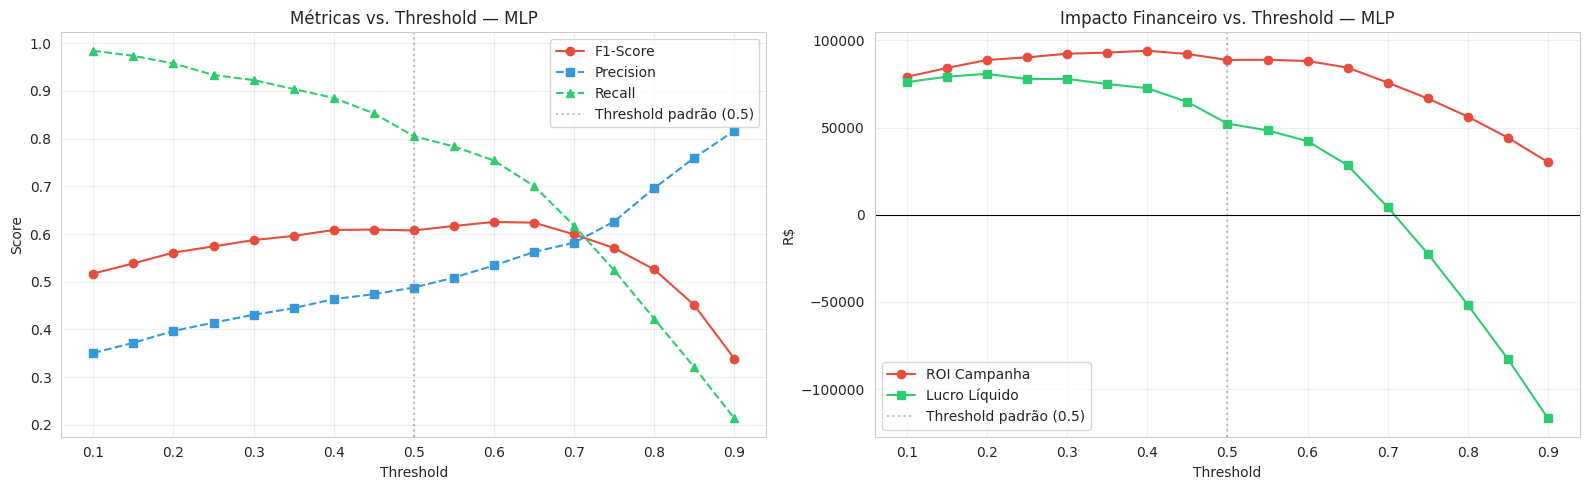


Threshold ótimo (lucro líquido): 0.20
  F1: 0.5611 | Precision: 0.3969 | Recall: 0.9572
  ROI Campanha: R$ 88,800
  Lucro Líquido: R$ 80,800


In [20]:
# Trade-off de custo por threshold — MLP
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

y_test_np = y_test_mlp.values if hasattr(y_test_mlp, "values") else y_test_mlp
y_proba_mlp_test = mlp_wrapper.predict_proba(X_test_mlp)[:, 1]

for t in thresholds:
    y_pred_t = (y_proba_mlp_test >= t).astype(int)
    cm_t = confusion_matrix(y_test_np, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    results.append({
        "threshold": t,
        "f1": f1_score(y_test_np, y_pred_t),
        "precision": precision_score(y_test_np, y_pred_t, zero_division=0),
        "recall": recall_score(y_test_np, y_pred_t),
        "roi_campanha": tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO) - fp * CUSTO_RETENCAO,
        "lucro_liquido": tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO) - fp * CUSTO_RETENCAO - fn * VALOR_CLIENTE_LTV,
    })

df_thresh = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Métricas técnicas vs threshold
axes[0].plot(df_thresh["threshold"], df_thresh["f1"], "o-", label="F1-Score", color="#e74c3c")
axes[0].plot(df_thresh["threshold"], df_thresh["precision"], "s--", label="Precision", color="#3498db")
axes[0].plot(df_thresh["threshold"], df_thresh["recall"], "^--", label="Recall", color="#2ecc71")
axes[0].axvline(0.5, color="gray", linestyle=":", alpha=0.5, label="Threshold padrão (0.5)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Métricas vs. Threshold — MLP")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Custo vs threshold
axes[1].plot(df_thresh["threshold"], df_thresh["roi_campanha"], "o-", label="ROI Campanha", color="#e74c3c")
axes[1].plot(df_thresh["threshold"], df_thresh["lucro_liquido"], "s-", label="Lucro Líquido", color="#2ecc71")
axes[1].axvline(0.5, color="gray", linestyle=":", alpha=0.5, label="Threshold padrão (0.5)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("R$")
axes[1].set_title("Impacto Financeiro vs. Threshold — MLP")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Threshold ótimo por lucro líquido
best_idx = df_thresh["lucro_liquido"].idxmax()
best_row = df_thresh.iloc[best_idx]
print(f"\nThreshold ótimo (lucro líquido): {best_row['threshold']:.2f}")
print(f"  F1: {best_row['f1']:.4f} | Precision: {best_row['precision']:.4f} | Recall: {best_row['recall']:.4f}")
print(f"  ROI Campanha: R$ {best_row['roi_campanha']:,.0f}")
print(f"  Lucro Líquido: R$ {best_row['lucro_liquido']:,.0f}")

### Cross-Validation + Grid Search

Validação robusta com `StratifiedKFold(5)` e busca sobre hiperparâmetros chave:
- `hidden_dims`: tamanho das camadas ocultas
- `dropout`: taxa de dropout
- `lr`: learning rate
- `batch_size`: tamanho do batch

Seleção via **média de ROC-AUC** nos folds de validação. Retreino final no train completo com a melhor configuração.

In [22]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import product

# Grid de hiperparâmetros
param_grid = {
    'hidden_dims': [(32, 16), (48, 24), (64, 32)],
    'dropout': [0.0, 0.1, 0.2],
    'lr': [0.001, 0.003],
    'batch_size': [16, 32],
}

# Gerar todas as combinações
keys = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Total de configurações: {len(combos)}")
print(f"Com 5 folds: {len(combos) * 5} treinos")

# Features e target do dataset MLP (antes do split train/test)
# Usamos o df_mlp_encoded que já passou pelo mlp_preprocessing
X_full = df_mlp_encoded.drop(columns=['target'])
y_full = df_mlp_encoded['target']

# Separar test set (mesmo split do modelo anterior)
X_cv_pool, X_test_cv, y_cv_pool, y_test_cv = train_test_split(
    X_full, y_full, test_size=TEST_SIZE, random_state=SEED, stratify=y_full
)

num_cols_mlp = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'charge_vs_expected', 'num_services', 'avg_charges_per_month']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def train_mlp_fold(X_tr, y_tr, X_vl, y_vl, hidden_dims, dropout, lr, batch_size, max_epochs=200, patience=25):
    """Treina MLP em um fold e retorna ROC-AUC no validation."""
    # Scaling
    scaler = StandardScaler()
    X_tr = X_tr.copy()
    X_vl = X_vl.copy()
    X_tr[num_cols_mlp] = scaler.fit_transform(X_tr[num_cols_mlp])
    X_vl[num_cols_mlp] = scaler.transform(X_vl[num_cols_mlp])

    # Tensores
    X_tr_t = torch.tensor(X_tr.values.astype(np.float32))
    y_tr_t = torch.tensor(y_tr.values.astype(np.float32))
    X_vl_t = torch.tensor(X_vl.values.astype(np.float32))
    y_vl_t = torch.tensor(y_vl.values.astype(np.float32))

    train_ds = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

    # pos_weight
    n_p = y_tr.sum()
    n_n = len(y_tr) - n_p
    pw = torch.tensor([n_n / n_p], dtype=torch.float32)

    # Modelo
    mdl = ChurnMLP(X_tr_t.shape[1], hidden_dims=hidden_dims, dropout=dropout)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10)

    best_vl = float('inf')
    best_state = None
    no_improve = 0

    for ep in range(1, max_epochs + 1):
        mdl.train()
        for xb, yb in train_ds:
            opt.zero_grad()
            loss = crit(mdl(xb), yb)
            loss.backward()
            opt.step()

        mdl.eval()
        with torch.no_grad():
            vl_logits = mdl(X_vl_t)
            vl_loss = crit(vl_logits, y_vl_t).item()
        sched.step(vl_loss)

        if vl_loss < best_vl:
            best_vl = vl_loss
            best_state = mdl.state_dict().copy()
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    # Avaliar melhor modelo
    mdl.load_state_dict(best_state)
    mdl.eval()
    with torch.no_grad():
        probs = torch.sigmoid(mdl(X_vl_t)).numpy()
    return roc_auc_score(y_vl.values, probs)


# --- Grid Search com Cross-Validation ---
results_cv = []

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    fold_aucs = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_cv_pool, y_cv_pool)):
        X_tr_fold = X_cv_pool.iloc[train_idx]
        y_tr_fold = y_cv_pool.iloc[train_idx]
        X_vl_fold = X_cv_pool.iloc[val_idx]
        y_vl_fold = y_cv_pool.iloc[val_idx]

        auc_val = train_mlp_fold(
            X_tr_fold, y_tr_fold, X_vl_fold, y_vl_fold,
            hidden_dims=params['hidden_dims'],
            dropout=params['dropout'],
            lr=params['lr'],
            batch_size=params['batch_size'],
        )
        fold_aucs.append(auc_val)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    results_cv.append({**params, 'mean_roc_auc': mean_auc, 'std_roc_auc': std_auc})

    if (i + 1) % 6 == 0 or i == 0:
        print(f"[{i+1}/{len(combos)}] {params} → AUC: {mean_auc:.4f} ± {std_auc:.4f}")

df_cv = pd.DataFrame(results_cv).sort_values('mean_roc_auc', ascending=False)
print(f"\n{'='*70}")
print("Top 5 configurações:")
print(df_cv.head().to_string(index=False))

Total de configurações: 36
Com 5 folds: 180 treinos
[1/36] {'hidden_dims': (32, 16), 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16} → AUC: 0.8359 ± 0.0111
[6/36] {'hidden_dims': (32, 16), 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32} → AUC: 0.8400 ± 0.0106
[12/36] {'hidden_dims': (32, 16), 'dropout': 0.2, 'lr': 0.003, 'batch_size': 32} → AUC: 0.8401 ± 0.0097
[18/36] {'hidden_dims': (48, 24), 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32} → AUC: 0.8368 ± 0.0099
[24/36] {'hidden_dims': (48, 24), 'dropout': 0.2, 'lr': 0.003, 'batch_size': 32} → AUC: 0.8374 ± 0.0094
[30/36] {'hidden_dims': (64, 32), 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32} → AUC: 0.8340 ± 0.0078
[36/36] {'hidden_dims': (64, 32), 'dropout': 0.2, 'lr': 0.003, 'batch_size': 32} → AUC: 0.8355 ± 0.0093

Top 5 configurações:
hidden_dims  dropout    lr  batch_size  mean_roc_auc  std_roc_auc
   (32, 16)      0.2 0.001          16      0.845717     0.011516
   (32, 16)      0.2 0.001          32      0.844578     0.010784
  

In [23]:
# Retreinar modelo final com a melhor configuração no train completo
best_params = df_cv.iloc[0]
print(f"Melhor configuração:")
print(f"  hidden_dims: {best_params['hidden_dims']}")
print(f"  dropout:     {best_params['dropout']}")
print(f"  lr:          {best_params['lr']}")
print(f"  batch_size:  {int(best_params['batch_size'])}")
print(f"  CV ROC-AUC:  {best_params['mean_roc_auc']:.4f} ± {best_params['std_roc_auc']:.4f}")

# Split train/val do pool (para early stopping no treino final)
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_cv_pool, y_cv_pool, test_size=0.15, random_state=SEED, stratify=y_cv_pool
)

# Scaling
scaler_final = StandardScaler()
X_train_final = X_train_final.copy()
X_val_final = X_val_final.copy()
X_test_final = X_test_cv.copy()
X_train_final[num_cols_mlp] = scaler_final.fit_transform(X_train_final[num_cols_mlp])
X_val_final[num_cols_mlp] = scaler_final.transform(X_val_final[num_cols_mlp])
X_test_final[num_cols_mlp] = scaler_final.transform(X_test_final[num_cols_mlp])

# Tensores
X_tr_t = torch.tensor(X_train_final.values.astype(np.float32))
y_tr_t = torch.tensor(y_train_final.values.astype(np.float32))
X_vl_t = torch.tensor(X_val_final.values.astype(np.float32))
y_vl_t = torch.tensor(y_val_final.values.astype(np.float32))
X_te_t = torch.tensor(X_test_final.values.astype(np.float32))
y_te_t = torch.tensor(y_test_cv.values.astype(np.float32))

best_bs = int(best_params['batch_size'])
train_loader_final = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=best_bs, shuffle=True)

# pos_weight
n_p = y_train_final.sum()
n_n = len(y_train_final) - n_p
pw_final = torch.tensor([n_n / n_p], dtype=torch.float32)

# Modelo final
torch.manual_seed(SEED)
model_final = ChurnMLP(
    X_tr_t.shape[1],
    hidden_dims=best_params['hidden_dims'],
    dropout=best_params['dropout'],
)
criterion_final = nn.BCEWithLogitsLoss(pos_weight=pw_final)
optimizer_final = torch.optim.Adam(model_final.parameters(), lr=best_params['lr'])
scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='min', factor=0.5, patience=10
)

best_vl_loss = float('inf')
best_state_final = None
no_improve = 0
PATIENCE_FINAL = 25

for epoch in range(1, 201):
    model_final.train()
    for xb, yb in train_loader_final:
        optimizer_final.zero_grad()
        loss = criterion_final(model_final(xb), yb)
        loss.backward()
        optimizer_final.step()

    model_final.eval()
    with torch.no_grad():
        vl_loss = criterion_final(model_final(X_vl_t), y_vl_t).item()
    scheduler_final.step(vl_loss)

    if vl_loss < best_vl_loss:
        best_vl_loss = vl_loss
        best_state_final = model_final.state_dict().copy()
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 20 == 0 or no_improve == 0:
        marker = " ✓" if no_improve == 0 else ""
        print(f"Epoch {epoch:3d} | Val Loss: {vl_loss:.4f}{marker}")

    if no_improve >= PATIENCE_FINAL:
        print(f"\nEarly stopping na época {epoch}")
        break

model_final.load_state_dict(best_state_final)
print(f"\nMelhor val loss: {best_vl_loss:.4f}")

# Avaliar no test set
mlp_final_wrapper = PyTorchWrapper(model_final, device)
print("\n" + "=" * 60)
print(" MLP FINAL (melhor config do grid search)")
print("=" * 60)
mlp_final_metrics, mlp_final_cm = evaluate_model(mlp_final_wrapper, X_test_final, y_test_cv)

Melhor configuração:
  hidden_dims: (32, 16)
  dropout:     0.2
  lr:          0.001
  batch_size:  16
  CV ROC-AUC:  0.8457 ± 0.0115
Epoch   1 | Val Loss: 0.7513 ✓
Epoch   2 | Val Loss: 0.7215 ✓
Epoch   3 | Val Loss: 0.7200 ✓
Epoch  20 | Val Loss: 0.7244

Early stopping na época 28

Melhor val loss: 0.7200

 MLP FINAL (melhor config do grid search)
              precision    recall  f1-score   support

   Sem churn       0.90      0.74      0.81      1035
   Com churn       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

  ROC-AUC:  0.8456
  PR-AUC:   0.6602
  TP Custo churn evitado:  R$ 117,200
  FN Custo churn perdido:  R$ 40,500
  FP Custo falso positivo: R$ 27,100
  ROI Campanha:            R$ 90,100  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 49,600  (ganho_tp - custo_fp - perda_fn)


### Otimização de Threshold (no validation set)

O threshold de 0.5 é arbitrário. Otimizamos no **validation set** (não no test!) para evitar data leakage, e aplicamos ao test para comparação final.

In [24]:
# --- Otimizar threshold no VALIDATION set ---
y_proba_val = mlp_final_wrapper.predict_proba(X_val_final)[:, 1]
y_val_np = y_val_final.values

thresholds_opt = np.arange(0.10, 0.91, 0.01)
val_results = []

for t in thresholds_opt:
    y_pred_t = (y_proba_val >= t).astype(int)
    cm_t = confusion_matrix(y_val_np, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    lucro = tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO) - fp * CUSTO_RETENCAO - fn * VALOR_CLIENTE_LTV
    val_results.append({
        'threshold': t,
        'lucro_liquido': lucro,
        'f1': f1_score(y_val_np, y_pred_t, zero_division=0),
        'roc_auc': roc_auc_score(y_val_np, y_proba_val),  # independente do threshold
    })

df_val_thresh = pd.DataFrame(val_results)
best_thresh_idx = df_val_thresh['lucro_liquido'].idxmax()
best_threshold = df_val_thresh.iloc[best_thresh_idx]['threshold']

print(f"Threshold ótimo (val, lucro líquido): {best_threshold:.2f}")
print(f"  Lucro líquido (val): R$ {df_val_thresh.iloc[best_thresh_idx]['lucro_liquido']:,.0f}")
print(f"  F1 (val): {df_val_thresh.iloc[best_thresh_idx]['f1']:.4f}")

# --- Aplicar threshold otimizado ao TEST set ---
mlp_opt_wrapper = PyTorchWrapper(model_final, device, threshold=best_threshold)

print("\n" + "=" * 60)
print(f" MLP FINAL — Threshold otimizado ({best_threshold:.2f})")
print("=" * 60)
mlp_opt_metrics, mlp_opt_cm = evaluate_model(mlp_opt_wrapper, X_test_final, y_test_cv)

# --- Otimizar threshold da LR no validation set também (comparação justa) ---
# Precisamos da LR treinada no mesmo split
lr_for_thresh = LogisticRegression(
    max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
)
# Usar o split de baseline (X_train/X_test do início)
y_proba_lr_test = lr.predict_proba(X_test)[:, 1]

# Threshold sweep na LR (no test dos baselines, para comparação)
lr_thresh_results = []
for t in thresholds_opt:
    y_pred_t = (y_proba_lr_test >= t).astype(int)
    cm_t = confusion_matrix(y_test.values, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    lucro = tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO) - fp * CUSTO_RETENCAO - fn * VALOR_CLIENTE_LTV
    lr_thresh_results.append({'threshold': t, 'lucro_liquido': lucro})

df_lr_thresh = pd.DataFrame(lr_thresh_results)
best_lr_thresh = df_lr_thresh.iloc[df_lr_thresh['lucro_liquido'].idxmax()]['threshold']
best_lr_lucro = df_lr_thresh['lucro_liquido'].max()

print(f"\nLR — threshold ótimo: {best_lr_thresh:.2f}, lucro líquido: R$ {best_lr_lucro:,.0f}")
print(f"MLP — threshold ótimo: {best_threshold:.2f}, lucro líquido: R$ {mlp_opt_metrics['lucro_liquido_BRL']:,.0f}")

Threshold ótimo (val, lucro líquido): 0.11
  Lucro líquido (val): R$ 44,600
  F1 (val): 0.5203

 MLP FINAL — Threshold otimizado (0.11)
              precision    recall  f1-score   support

   Sem churn       0.98      0.37      0.54      1035
   Com churn       0.36      0.98      0.53       374

    accuracy                           0.53      1409
   macro avg       0.67      0.67      0.53      1409
weighted avg       0.81      0.53      0.53      1409

  ROC-AUC:  0.8456
  PR-AUC:   0.6602
  TP Custo churn evitado:  R$ 146,400
  FN Custo churn perdido:  R$ 4,000
  FP Custo falso positivo: R$ 65,400
  ROI Campanha:            R$ 81,000  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 77,000  (ganho_tp - custo_fp - perda_fn)

LR — threshold ótimo: 0.20, lucro líquido: R$ 82,300
MLP — threshold ótimo: 0.11, lucro líquido: R$ 77,000


### Comparação Final: Todos os Modelos

In [25]:
# Tabela comparativa completa: todos os modelos
all_metric_keys = list(dummy_metrics.keys())
resumo_final = pd.DataFrame({
    "Metrica": all_metric_keys,
    "DummyClassifier": [dummy_metrics[m] for m in all_metric_keys],
    "LogisticRegression": [lr_metrics[m] for m in all_metric_keys],
    "MLP (default)": [mlp_metrics[m] for m in all_metric_keys],
    "MLP (grid search)": [mlp_final_metrics[m] for m in all_metric_keys],
    "MLP (thresh otim.)": [mlp_opt_metrics[m] for m in all_metric_keys],
})

resumo_final_display = resumo_final.copy()
for col in ["DummyClassifier", "LogisticRegression", "MLP (default)", "MLP (grid search)", "MLP (thresh otim.)"]:
    resumo_final_display[col] = resumo_final.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

print("=" * 90)
print(" COMPARAÇÃO FINAL: Baselines vs. MLP (todas as variantes)")
print("=" * 90)
resumo_final_display

 COMPARAÇÃO FINAL: Baselines vs. MLP (todas as variantes)


,Metrica,DummyClassifier,LogisticRegression,MLP (default),MLP (grid search),MLP (thresh otim.)
0,accuracy,0.7346,0.7459,0.7239,0.7502,0.5302
1,f1_score,0.0000,0.6247,0.6075,0.6247,0.5251
2,precision,0.0000,0.5138,0.4878,0.5195,0.3588
3,recall,0.0000,0.7968,0.8048,0.7834,0.9786
4,roc_auc,0.5000,0.8473,0.8412,0.8456,0.8456
5,pr_auc,0.6327,0.6660,0.6505,0.6602,0.6602
6,custo_churn_evitado_BRL,R$ 0,"R$ 119,200","R$ 120,400","R$ 117,200","R$ 146,400"
7,custo_falso_positivo_BRL,R$ 0,"R$ 28,200","R$ 31,600","R$ 27,100","R$ 65,400"
8,custo_churn_perdido_BRL,"R$ 187,000","R$ 38,000","R$ 36,500","R$ 40,500","R$ 4,000"
9,roi_campanha_BRL,R$ 0,"R$ 91,000","R$ 88,800","R$ 90,100","R$ 81,000"


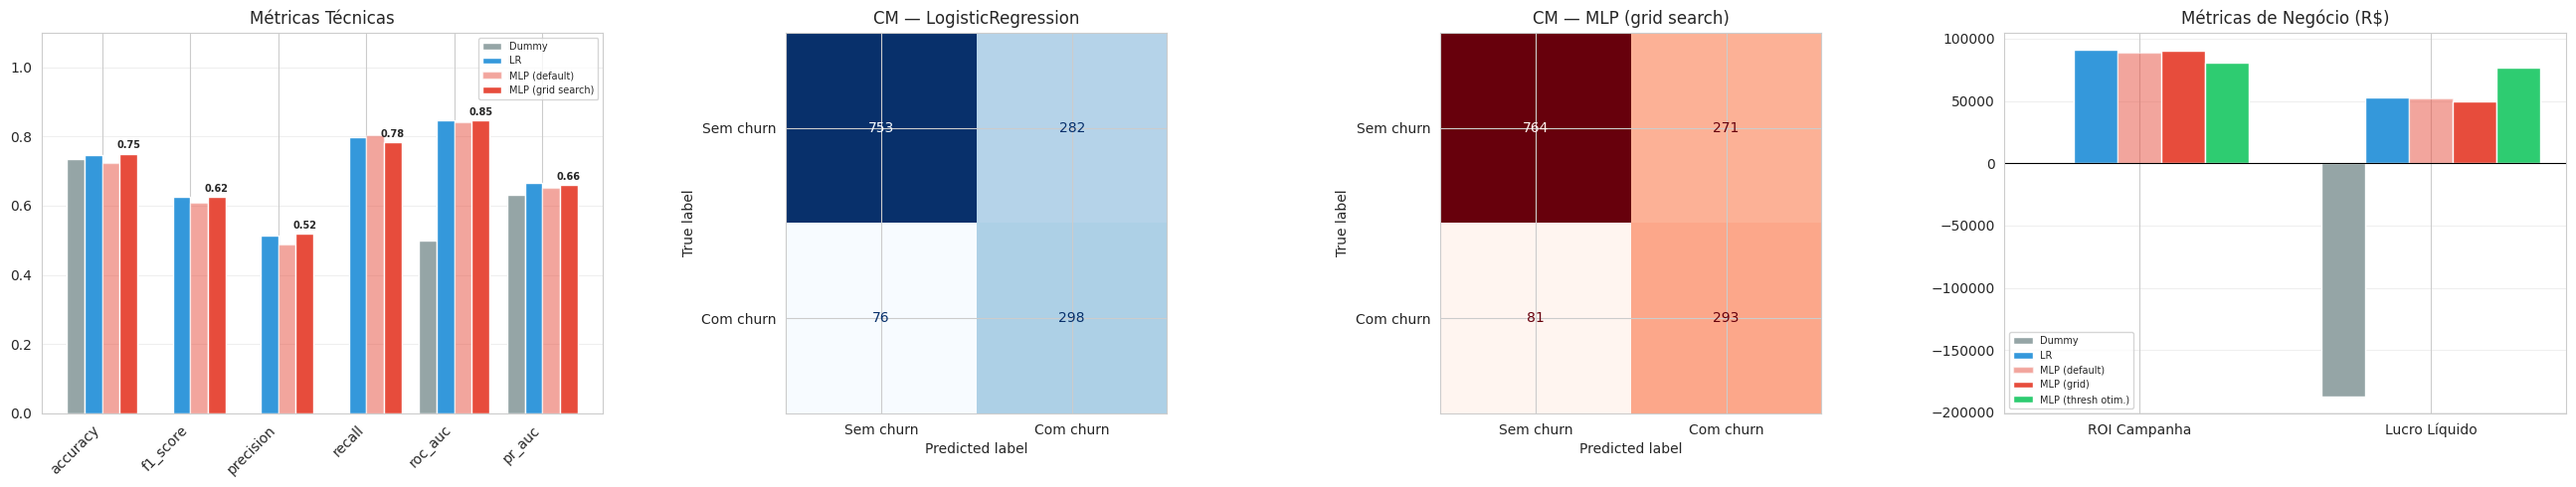

In [26]:
# Visualização final — todos os modelos
fig, axes = plt.subplots(1, 4, figsize=(26, 5))

metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]
mlp_vals = [mlp_metrics[m] for m in metric_names]
mlp_final_vals = [mlp_final_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.2
axes[0].bar(x - 1.5*width, dummy_vals, width, label="Dummy", color="#95a5a6")
axes[0].bar(x - 0.5*width, lr_vals, width, label="LR", color="#3498db")
axes[0].bar(x + 0.5*width, mlp_vals, width, label="MLP (default)", color="#e74c3c", alpha=0.5)
bars_final = axes[0].bar(x + 1.5*width, mlp_final_vals, width, label="MLP (grid search)", color="#e74c3c")
for bar in bars_final:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7, fontweight="bold",
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Métricas Técnicas")
axes[0].legend(fontsize=7)
axes[0].grid(axis="y", alpha=0.3)

ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("CM — LogisticRegression")

ConfusionMatrixDisplay(mlp_final_cm, display_labels=["Sem churn", "Com churn"]).plot(ax=axes[2], cmap="Reds", colorbar=False)
axes[2].set_title("CM — MLP (grid search)")

biz_metrics = ["roi_campanha_BRL", "lucro_liquido_BRL"]
biz_labels = ["ROI Campanha", "Lucro Líquido"]
dummy_biz = [dummy_metrics[m] for m in biz_metrics]
lr_biz = [lr_metrics[m] for m in biz_metrics]
mlp_biz = [mlp_metrics[m] for m in biz_metrics]
mlp_final_biz = [mlp_final_metrics[m] for m in biz_metrics]
mlp_opt_biz = [mlp_opt_metrics[m] for m in biz_metrics]

x_biz = np.arange(len(biz_metrics))
w = 0.15
axes[3].bar(x_biz - 2*w, dummy_biz, w, label="Dummy", color="#95a5a6")
axes[3].bar(x_biz - w, lr_biz, w, label="LR", color="#3498db")
axes[3].bar(x_biz, mlp_biz, w, label="MLP (default)", color="#e74c3c", alpha=0.5)
axes[3].bar(x_biz + w, mlp_final_biz, w, label="MLP (grid)", color="#e74c3c")
axes[3].bar(x_biz + 2*w, mlp_opt_biz, w, label="MLP (thresh otim.)", color="#2ecc71")
axes[3].set_xticks(x_biz)
axes[3].set_xticklabels(biz_labels)
axes[3].set_title("Métricas de Negócio (R$)")
axes[3].legend(fontsize=7)
axes[3].grid(axis="y", alpha=0.3)
axes[3].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()